=== Q9 Setup ===
Fig.6 dirt cells: [(2, 1), (2, 2), (3, 2), (3, 3), (4, 3), (4, 4), (5, 4), (5, 5), (6, 5), (6, 6)]
Start (charging station): (1, 1)
Costs: HV=1.0, Diag=1.414 | Clean reward=+10

--- BASELINE (goal-based greedy, 4-direction + return) ---
Total steps: 20
Trace: [(1, 1), (2, 1), (2, 2), (3, 2), (3, 3), (4, 3), (4, 4), (5, 4), (5, 5), (6, 5), (6, 6), (6, 5), (6, 4), (6, 3), (6, 2), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (1, 1)]

--- IMPROVED (A* 8-direction + DP optimal order + return) ---
Total steps: 11
Trace: [(1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (6, 5), (5, 4), (4, 3), (3, 2), (2, 1), (1, 1)]

=== Baseline Frames ===


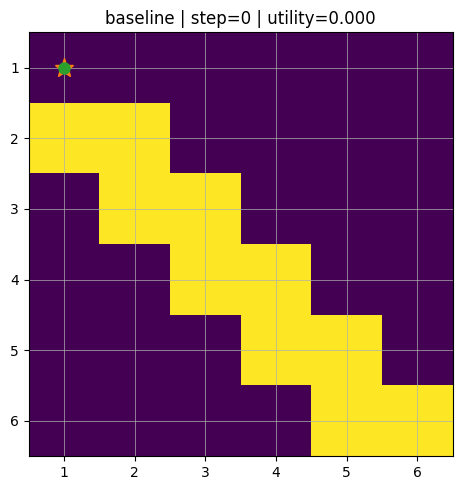

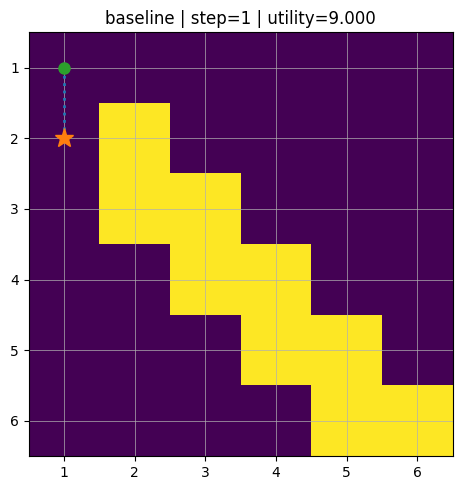

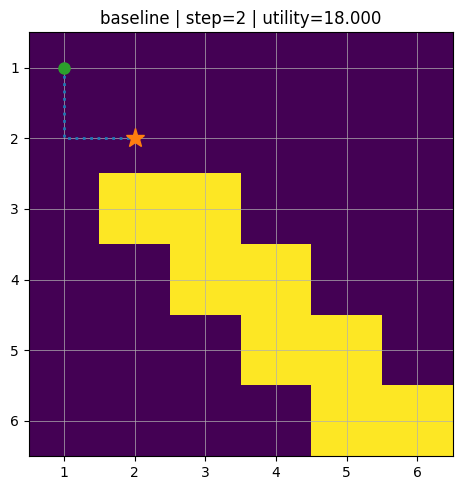

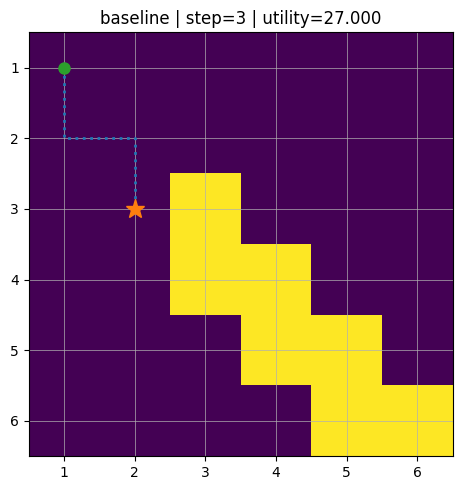

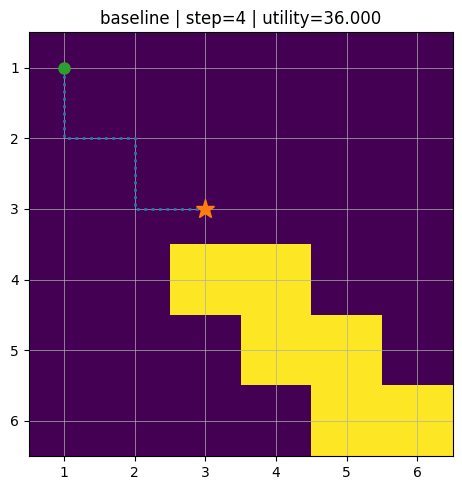

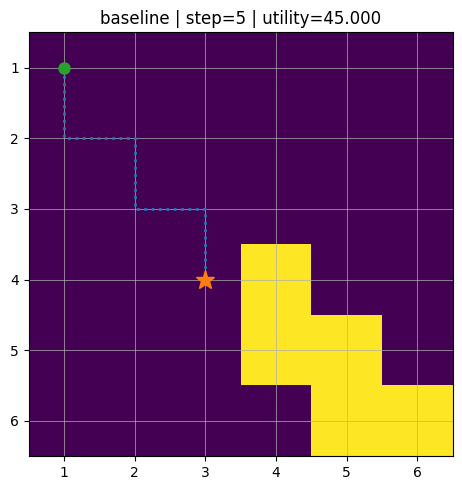

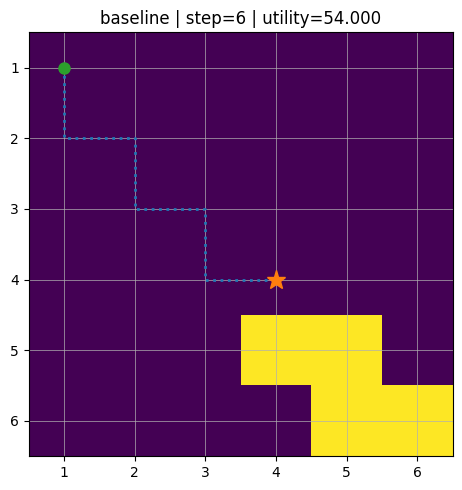

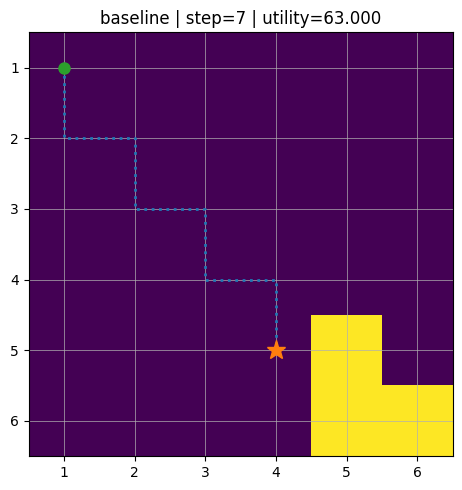

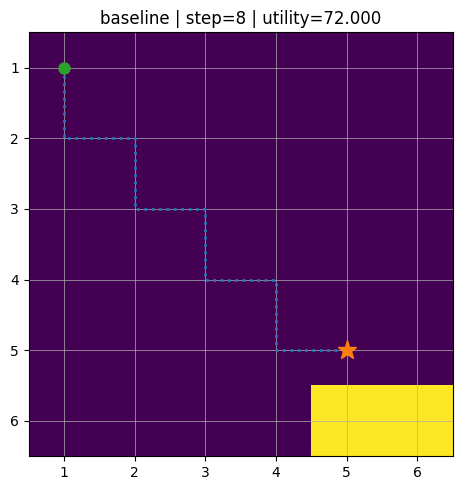

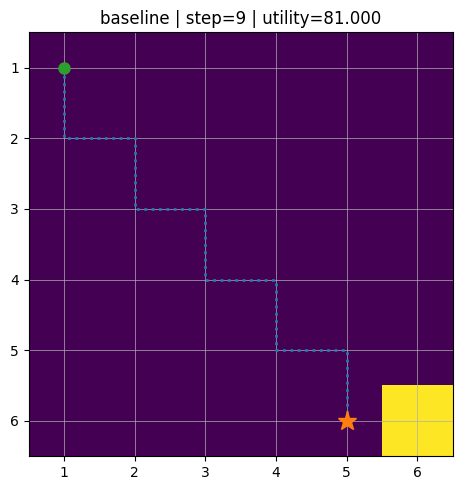

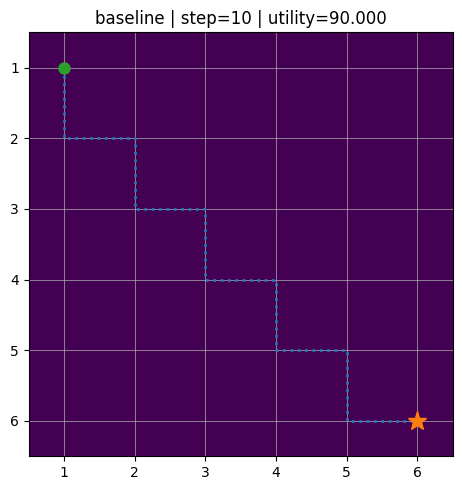

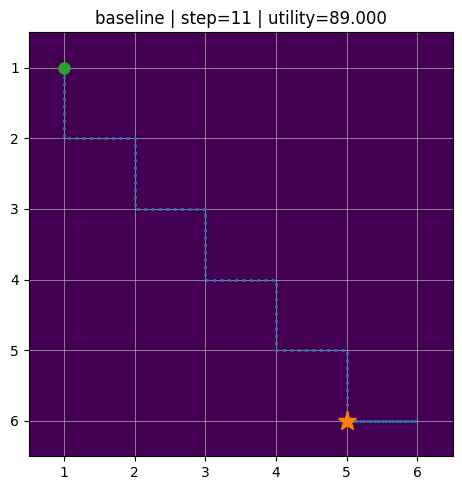

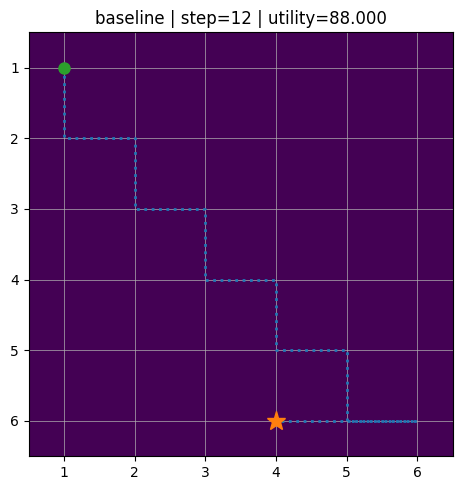

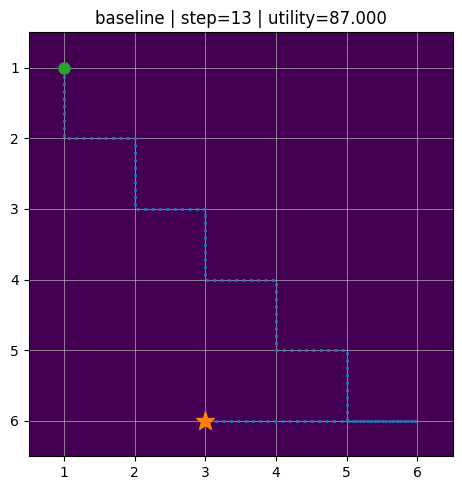

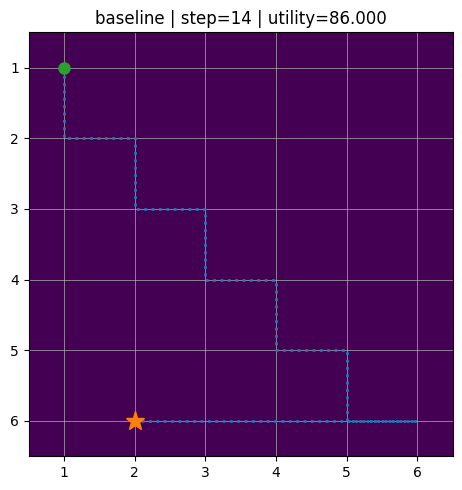

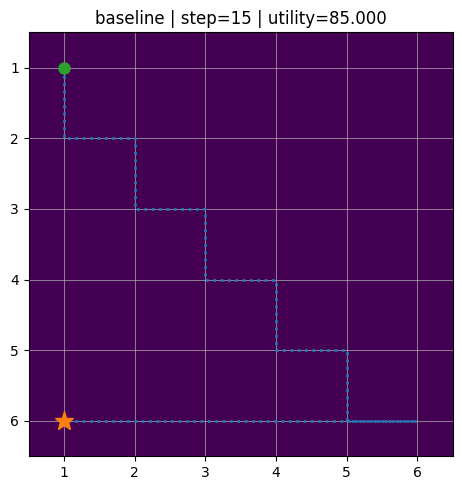

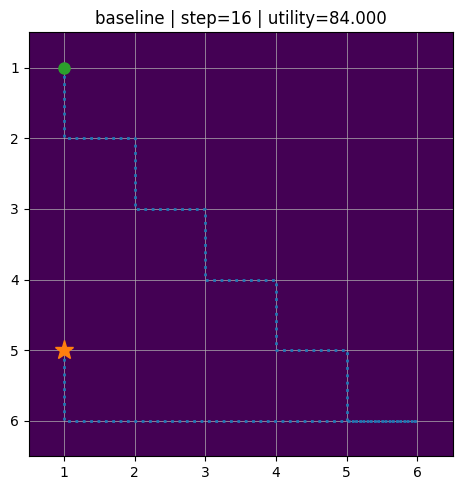

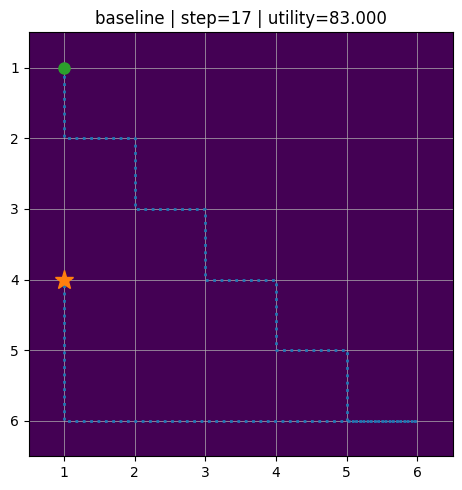

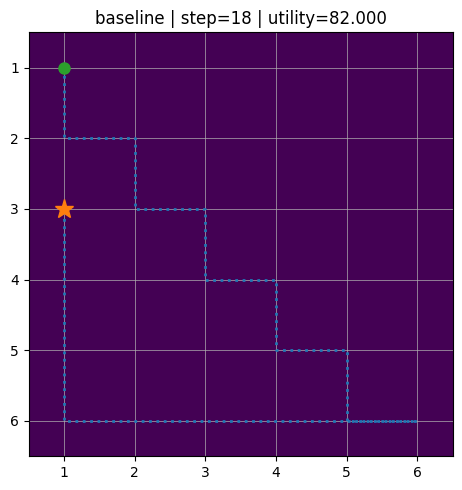

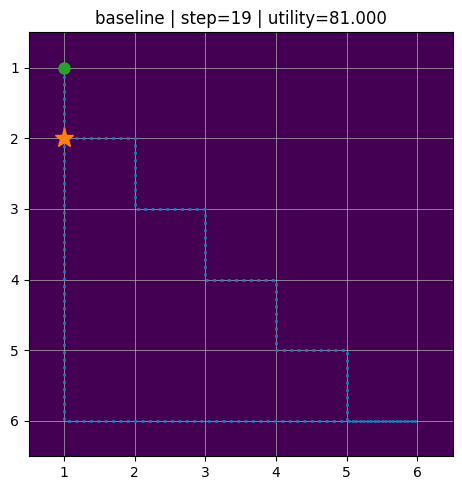

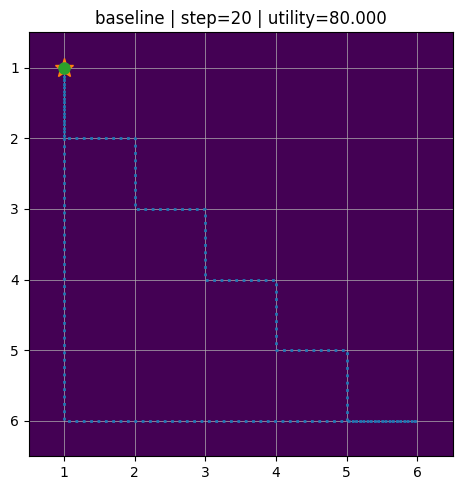


=== Improved Frames ===


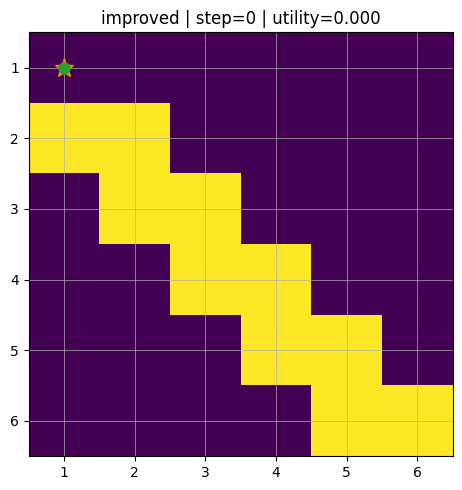

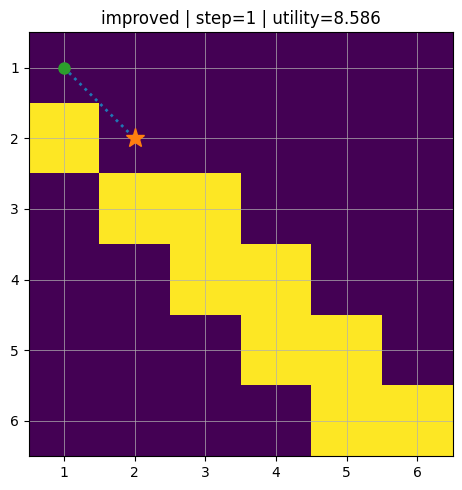

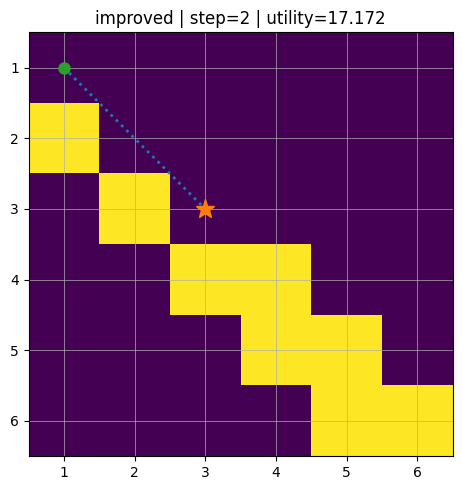

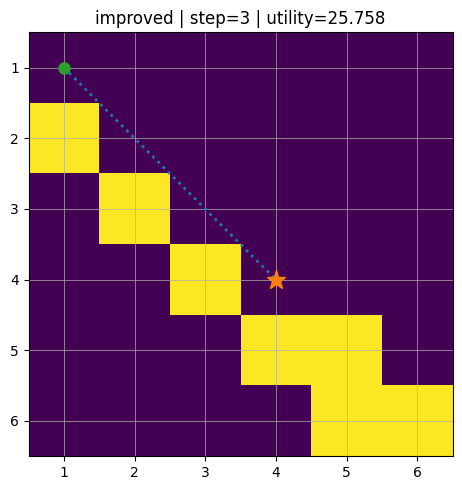

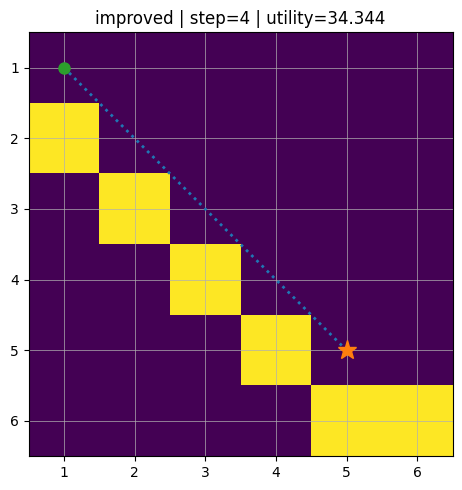

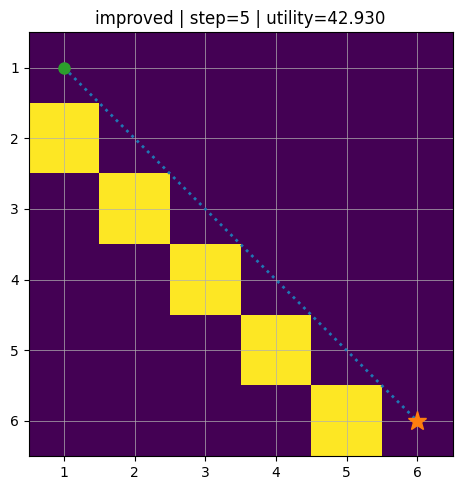

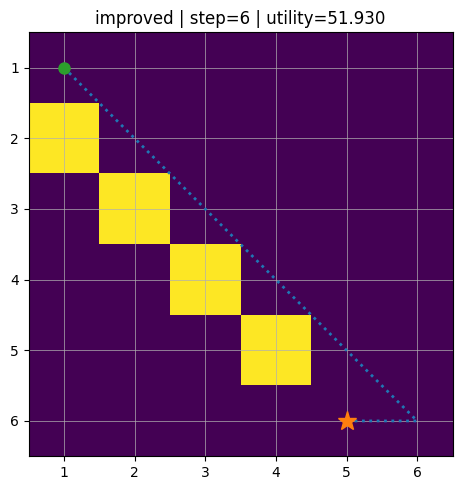

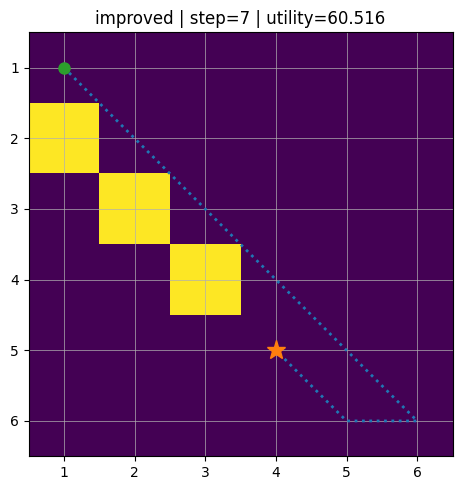

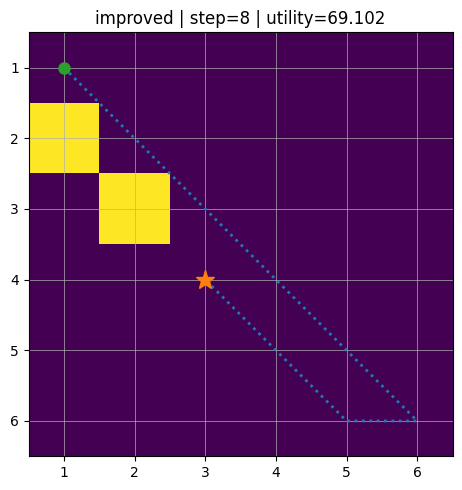

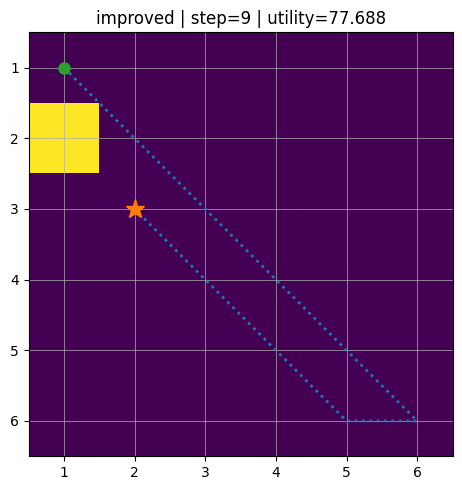

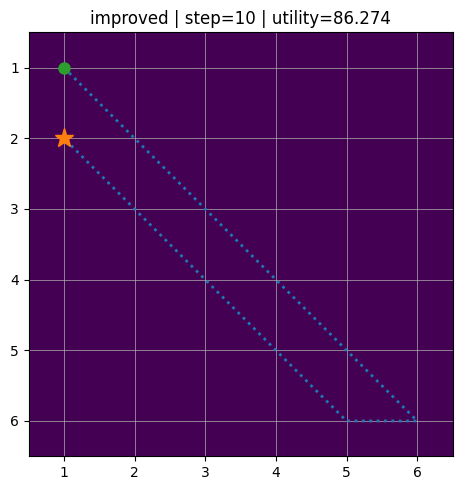

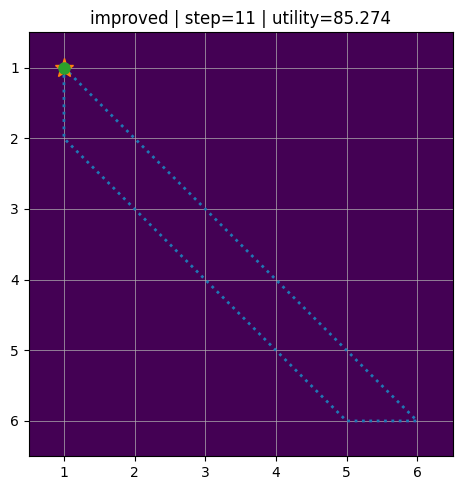


===== FINAL RESULTS =====
Baseline utility: 80.000
Improved utility: 85.274
Screenshots saved in: q9_frames/

=== Utility Math (quick check) ===
Total dirt: 10 => reward = 100.0
Baseline cost: 20.0 => utility = 80.0
Improved cost: 9*1.414 + 2*1.0 = 14.726 => utility = 100.0 - 14.726 = 85.274

=== What I did / why improved is better ===
Baseline is basically greedy: find the closest dirt (4-direction), clean it, repeat, then go back to (1,1).
My improved one allows diagonals and uses A* for shortest-cost moves, plus a DP route pick so the overall order is cheaper.
Same +10 per dirt either way, so less movement cost = higher final utility.


In [ ]:
# Noah Russell 
# Baseline (goal-based greedy) + Improved (A* + optimal visit order + return to base)

import math
import heapq
import os
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt

HV_COST = 1.0
DIAG_COST = 1.414
CLEAN_REWARD = 10.0

START = (1, 1)
N = 6  # 6x6 board

# Fig. 6 dirt pattern (stair-step diagonal band)
DIRT_FIG6 = sorted([
    (2,1),(2,2),
    (3,2),(3,3),
    (4,3),(4,4),
    (5,4),(5,5),
    (6,5),(6,6),
])

# ---------- Helpers ----------
def in_bounds(rc: Tuple[int,int]) -> bool:
    r, c = rc
    return 1 <= r <= N and 1 <= c <= N

def neighbors_8(rc: Tuple[int,int]) -> List[Tuple[Tuple[int,int], float]]:
    r, c = rc
    moves = [
        ((r-1,c), HV_COST), ((r+1,c), HV_COST), ((r,c-1), HV_COST), ((r,c+1), HV_COST),
        ((r-1,c-1), DIAG_COST), ((r-1,c+1), DIAG_COST), ((r+1,c-1), DIAG_COST), ((r+1,c+1), DIAG_COST),
    ]
    out = [(nxt, cost) for (nxt, cost) in moves if in_bounds(nxt)]
    # deterministic tie-break
    out.sort(key=lambda x: (x[0][0], x[0][1], x[1]))
    return out

def neighbors_4(rc: Tuple[int,int]) -> List[Tuple[Tuple[int,int], float]]:
    r, c = rc
    moves = [((r-1,c), 1.0), ((r,c-1), 1.0), ((r,c+1), 1.0), ((r+1,c), 1.0)]
    out = [(nxt, cost) for (nxt, cost) in moves if in_bounds(nxt)]

    # deterministic order similar to goal.py: Left, Up, Right, Down
    pref = {(r,c-1):0, (r-1,c):1, (r,c+1):2, (r+1,c):3}
    out.sort(key=lambda x: (pref.get(x[0], 99), x[0][0], x[0][1]))
    return out

def octile_heuristic(a: Tuple[int,int], b: Tuple[int,int]) -> float:
    dr = abs(a[0]-b[0])
    dc = abs(a[1]-b[1])
    dmin = min(dr, dc)
    dmax = max(dr, dc)
    return DIAG_COST*dmin + HV_COST*(dmax - dmin)

def reconstruct_path(came_from: Dict[Tuple[int,int], Tuple[int,int]], goal: Tuple[int,int]) -> List[Tuple[int,int]]:
    path = [goal]
    cur = goal
    while cur in came_from:
        cur = came_from[cur]
        path.append(cur)
    path.reverse()
    return path

def astar_8(start: Tuple[int,int], goal: Tuple[int,int]) -> Tuple[List[Tuple[int,int]], float]:
    if start == goal:
        return [start], 0.0

    open_heap = []
    heapq.heappush(open_heap, (octile_heuristic(start, goal), 0.0, start))
    came_from: Dict[Tuple[int,int], Tuple[int,int]] = {}
    g: Dict[Tuple[int,int], float] = {start: 0.0}

    while open_heap:
        f, cur_g, cur = heapq.heappop(open_heap)
        if cur == goal:
            return reconstruct_path(came_from, goal), cur_g

        for nxt, step_cost in neighbors_8(cur):
            new_g = cur_g + step_cost
            if (nxt not in g) or (new_g < g[nxt] - 1e-12):
                g[nxt] = new_g
                came_from[nxt] = cur
                new_f = new_g + octile_heuristic(nxt, goal)
                heapq.heappush(open_heap, (new_f, new_g, nxt))

    raise RuntimeError("A* failed (shouldn't happen on open grid).")

def bfs_4_path_to_nearest_dirt(start: Tuple[int,int], dirt_set: set) -> Optional[List[Tuple[int,int]]]:
    from collections import deque
    q = deque([start])
    parent = {start: None}

    found_goal = None
    while q:
        cur = q.popleft()
        if cur in dirt_set:
            found_goal = cur
            break
        for nxt, _ in neighbors_4(cur):
            if nxt not in parent:
                parent[nxt] = cur
                q.append(nxt)

    if found_goal is None:
        return None

    path = []
    cur = found_goal
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    return path

# ---------- Rendering ----------
def grid_to_matrix(dirt_set: set) -> List[List[int]]:
    mat = [[0 for _ in range(N)] for _ in range(N)]
    for (r,c) in dirt_set:
        mat[r-1][c-1] = 2
    return mat

def render(mat, path_so_far: List[Tuple[int,int]], utility: float, step_idx: int, title: str,
           save_path: Optional[str]=None, show_inline: bool=True):
    plt.figure(figsize=(5,5))
    plt.title(f"{title} | step={step_idx} | utility={utility:.3f}")
    plt.imshow(mat, interpolation="nearest")
    plt.xticks(range(N), [str(i) for i in range(1, N+1)])
    plt.yticks(range(N), [str(i) for i in range(1, N+1)])
    plt.grid(True, which='both', linewidth=0.5)

    xs = [rc[1]-1 for rc in path_so_far]  # col
    ys = [rc[0]-1 for rc in path_so_far]  # row
    plt.plot(xs, ys, linestyle=':', linewidth=2)
    plt.plot(xs[-1], ys[-1], marker='*', markersize=14)
    plt.plot(START[1]-1, START[0]-1, marker='o', markersize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    if show_inline:
        plt.show()
    plt.close()

# ---------- Simulator (frame-by-frame) ----------
def simulate(full_path: List[Tuple[int,int]], dirt_cells: List[Tuple[int,int]], title: str, screenshot_dir: str,
             show_inline: bool=True) -> float:
    dirt_set = set(dirt_cells)
    utility = 0.0
    cleaned = set()

    os.makedirs(screenshot_dir, exist_ok=True)

    # step 0
    render(grid_to_matrix(dirt_set), [full_path[0]], utility, 0, title,
           save_path=os.path.join(screenshot_dir, f"{title}_step_000.png"),
           show_inline=show_inline)

    # steps 1..end
    for i in range(1, len(full_path)):
        prev = full_path[i-1]
        cur = full_path[i]

        dr = abs(cur[0]-prev[0])
        dc = abs(cur[1]-prev[1])

        if dr == 1 and dc == 1:
            utility -= DIAG_COST
        elif dr + dc == 1:
            utility -= HV_COST
        else:
            raise ValueError(f"Invalid move from {prev} to {cur}")

        if cur in dirt_set and cur not in cleaned:
            cleaned.add(cur)
            utility += CLEAN_REWARD
            dirt_set.remove(cur)

        render(grid_to_matrix(dirt_set), full_path[:i+1], utility, i, title,
               save_path=os.path.join(screenshot_dir, f"{title}_step_{i:03d}.png"),
               show_inline=show_inline)

    return utility

# ---------- Baseline agent ----------
def baseline_goal_like(start: Tuple[int,int], dirt_cells: List[Tuple[int,int]]) -> List[Tuple[int,int]]:
    dirt_set = set(dirt_cells)
    cur = start
    full_path = [cur]

    while dirt_set:
        path = bfs_4_path_to_nearest_dirt(cur, dirt_set)
        if path is None:
            break
        full_path.extend(path[1:])
        cur = full_path[-1]
        if cur in dirt_set:
            dirt_set.remove(cur)

    # return to charging station
    back_path = bfs_4_path_to_nearest_dirt(cur, {start})
    if back_path is None:
        raise RuntimeError("Couldn't return to start.")
    full_path.extend(back_path[1:])
    return full_path

# ---------- Improved agent ----------
def compute_pairwise_paths(points: List[Tuple[int,int]]):
    dist = {a:{} for a in points}
    path = {a:{} for a in points}
    for a in points:
        for b in points:
            if a == b:
                dist[a][b] = 0.0
                path[a][b] = [a]
            else:
                p, d = astar_8(a, b)
                dist[a][b] = d
                path[a][b] = p
    return dist, path

def held_karp_tsp(start: Tuple[int,int], targets: List[Tuple[int,int]], dist):
    idx = {t:i for i,t in enumerate(targets)}
    m = len(targets)
    FULL = (1<<m) - 1

    dp = [dict() for _ in range(1<<m)]
    parent = [dict() for _ in range(1<<m)]

    for j,t in enumerate(targets):
        mask = (1<<j)
        dp[mask][j] = dist[start][t]
        parent[mask][j] = None

    for mask in range(1<<m):
        for j in list(dp[mask].keys()):
            for k,t_k in enumerate(targets):
                if mask & (1<<k):
                    continue
                new_mask = mask | (1<<k)
                t_j = targets[j]
                cand = dp[mask][j] + dist[t_j][t_k]
                if (k not in dp[new_mask]) or (cand < dp[new_mask][k] - 1e-12):
                    dp[new_mask][k] = cand
                    parent[new_mask][k] = j

    best_cost = float("inf")
    best_last = None
    for j,t_j in enumerate(targets):
        cand = dp[FULL][j] + dist[t_j][start]
        if cand < best_cost - 1e-12 or (abs(cand-best_cost) <= 1e-12 and (best_last is None or j < best_last)):
            best_cost = cand
            best_last = j

    order = []
    mask = FULL
    j = best_last
    while j is not None:
        order.append(targets[j])
        pj = parent[mask][j]
        mask = mask ^ (1<<idx[targets[j]])
        j = pj
    order.reverse()
    return best_cost, order

def improved_agent_path(start: Tuple[int,int], dirt_cells: List[Tuple[int,int]]) -> List[Tuple[int,int]]:
    targets = sorted(dirt_cells)  # deterministic
    points = [start] + targets
    dist, paths = compute_pairwise_paths(points)

    _, visit_order = held_karp_tsp(start, targets, dist)

    full = [start]
    cur = start
    for t in visit_order:
        seg = paths[cur][t]
        full.extend(seg[1:])
        cur = t
    seg = paths[cur][start]
    full.extend(seg[1:])
    return full

# ---------- Run everything ----------
print("=== Q9 Setup ===")
print("Fig.6 dirt cells:", DIRT_FIG6)
print("Start (charging station):", START)
print("Costs: HV=1.0, Diag=1.414 | Clean reward=+10\n")

baseline_path = baseline_goal_like(START, DIRT_FIG6)
smart_path = improved_agent_path(START, DIRT_FIG6)

print("--- BASELINE (goal-based greedy, 4-direction + return) ---")
print("Total steps:", len(baseline_path)-1)
print("Trace:", baseline_path)

print("\n--- IMPROVED (A* 8-direction + DP optimal order + return) ---")
print("Total steps:", len(smart_path)-1)
print("Trace:", smart_path)

print("\n=== Baseline Frames ===")
base_utility = simulate(baseline_path, DIRT_FIG6, "baseline", "q9_frames", show_inline=True)

print("\n=== Improved Frames ===")
smart_utility = simulate(smart_path, DIRT_FIG6, "improved", "q9_frames", show_inline=True)

print("\n===== FINAL RESULTS =====")
print(f"Baseline utility: {base_utility:.3f}")
print(f"Improved utility: {smart_utility:.3f}")
print("Screenshots saved in: q9_frames/")

# quick math check (super clear for the grader)
reward_total = len(DIRT_FIG6) * CLEAN_REWARD
baseline_cost = (len(baseline_path)-1) * HV_COST  # baseline uses HV only
print("\n=== Utility Math (quick check) ===")
print("Total dirt:", len(DIRT_FIG6), "=> reward =", reward_total)
print("Baseline cost:", baseline_cost, "=> utility =", reward_total - baseline_cost)

diag = 0
hv = 0
for i in range(1, len(smart_path)):
    a = smart_path[i-1]
    b = smart_path[i]
    dr = abs(a[0]-b[0])
    dc = abs(a[1]-b[1])
    if dr == 1 and dc == 1:
        diag += 1
    else:
        hv += 1
improved_cost = diag*DIAG_COST + hv*HV_COST
print(f"Improved cost: {diag}*1.414 + {hv}*1.0 = {improved_cost:.3f} => utility = {reward_total:.1f} - {improved_cost:.3f} = {smart_utility:.3f}")

print("\n=== What I did / why improved is better ===")
print("Baseline is basically greedy: find the closest dirt (4-direction), clean it, repeat, then go back to (1,1).")
print("My improved one allows diagonals and uses A* for shortest-cost moves, plus a DP route pick so the overall order is cheaper.")
print("Same +10 per dirt either way, so less movement cost = higher final utility.")
